# Scary Stochastics, Week 3: Brownian Motion
## Notebook 1 of 3 — One Zombie, the Physics

Brownian motion started out as a model for how physical particles diffuse through space — a random walk with Gaussian steps. A shambling zombie is, mathematically, exactly that. This notebook simulates many independent 2D Brownian paths, then checks the defining statistical signature of Brownian motion: **Mean Squared Displacement (MSD) grows linearly with time.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Zombie outbreak palette (extends the series palette with zombie green + cured steel blue)
PALETTE = {
    "red":    "#C8102E",  # candy red - patient zero marker
    "orange": "#E8741C",
    "rust":   "#B5451B",
    "purple": "#3B2145",
    "mustard":"#D9A404",
    "green":  "#6B8E23",  # zombie green - infected
    "blue":   "#4682B4",  # cured / steel blue - recovered
    "slate":  "#8C8C7A",  # susceptible - untouched humans
    "black":  "#1B1B1B",
    "cream":  "#FBF3E1",
}

STATE_NAMES = ["Susceptible", "Infected", "Recovered"]
STATE_COLORS = {"Susceptible": PALETTE["slate"], "Infected": PALETTE["green"], "Recovered": PALETTE["blue"]}

# Shared simulation constants
POP_SIZE = 180
TOWN_SIZE = 100.0
N_STEPS = 150
SIGMA = 1.5            # shambling step size (per-tick movement std)
CONTACT_RADIUS = 3.0
INFECTION_PROB = 0.15
RECOVERY_PROB = 0.02

plt.rcParams.update({
    "figure.facecolor": PALETTE["cream"],
    "axes.facecolor": PALETTE["cream"],
    "axes.edgecolor": PALETTE["black"],
    "text.color": PALETTE["black"],
    "axes.labelcolor": PALETTE["black"],
    "xtick.color": PALETTE["black"],
    "ytick.color": PALETTE["black"],
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

### Simulate 300 independent zombie paths

In [2]:
# Simulate many independent 2D Brownian paths (one zombie each)
N_PATHS = 300
steps_all = np.random.normal(0, SIGMA, size=(N_PATHS, N_STEPS, 2))
paths_all = np.cumsum(steps_all, axis=1)  # displacement from origin at each step
t_vals = np.arange(1, N_STEPS + 1)

### Visual 1 — One zombie's random walk

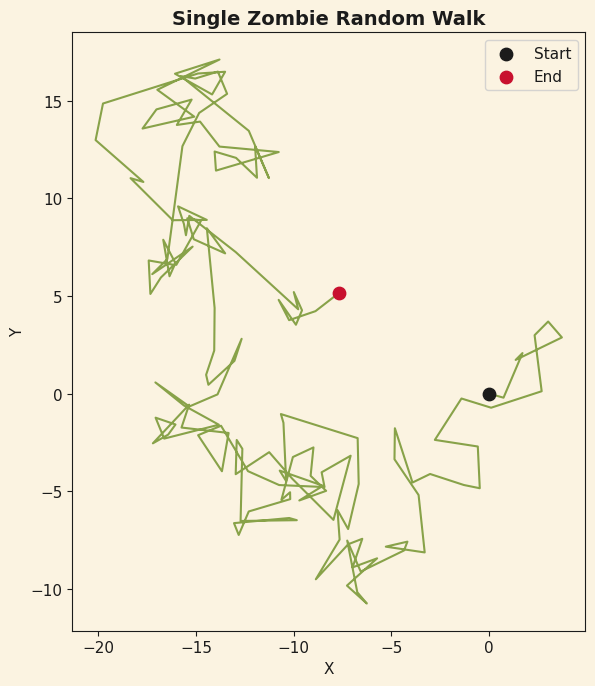

In [3]:
single_path = np.vstack([[0, 0], paths_all[0]])

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(single_path[:, 0], single_path[:, 1], color=PALETTE["green"], linewidth=1.5, alpha=0.8)
ax.scatter(*single_path[0], color=PALETTE["black"], s=80, zorder=3, label="Start")
ax.scatter(*single_path[-1], color=PALETTE["red"], s=80, zorder=3, label="End")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Single Zombie Random Walk")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("01_single_walk.png", dpi=150, facecolor=PALETTE["cream"])
plt.show()

### Visual 2 — Does MSD grow linearly with time?

Averaging squared displacement from the origin across all 300 paths at each time step, against the theoretical line MSD(t) = 2σ²t (the 2D Brownian motion prediction).

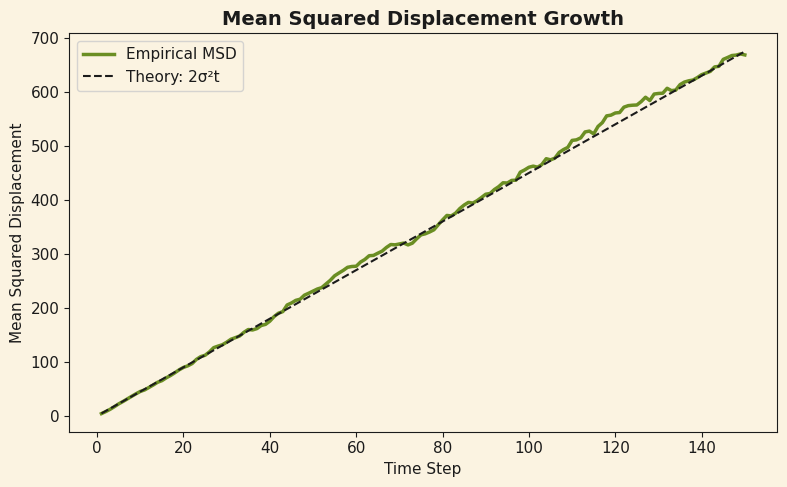

In [4]:
squared_disp = (paths_all ** 2).sum(axis=2)      # shape (N_PATHS, N_STEPS)
msd_empirical = squared_disp.mean(axis=0)
msd_theory = 2 * SIGMA ** 2 * t_vals

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t_vals, msd_empirical, color=PALETTE["green"], linewidth=2.5, label="Empirical MSD")
ax.plot(t_vals, msd_theory, color=PALETTE["black"], linestyle="--", linewidth=1.5,
        label="Theory: 2σ²t")
ax.set_xlabel("Time Step")
ax.set_ylabel("Mean Squared Displacement")
ax.set_title("Mean Squared Displacement Growth")
ax.legend()
plt.tight_layout()
plt.savefig("02_msd_growth.png", dpi=150, facecolor=PALETTE["cream"])
plt.show()

### Up next

Notebook 2 scales this up to a whole town, with an infection spreading through contact between independently wandering people.